In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew, zscore

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

FS = 2000
DATA_DIR = Path("/home/mamunds/job/pyspark/konux/data")


In [2]:
def load_binary_signal(filepath):
    return np.fromfile(filepath, dtype=np.float32)

def parse_filename_metadata(filename):
    meta = {}
    m = re.match(r"(\d{8})_(\d{6})_(\d+)_", filename)
    if m:
        meta["date"], meta["time"], meta["sensor_id"] = m.groups()
    return meta

def bandpass_filter_zero_phase(x, fs, low=5, high=500, order=4):
    x = x - np.mean(x)
    b, a = signal.butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return signal.filtfilt(b, a, x)

def rms_envelope(x, fs, window_s=0.05):
    w = max(1, int(window_s * fs))
    return np.sqrt(np.convolve(x**2, np.ones(w)/w, mode="same"))

def segment_active_region(env, fs):
    baseline = env[:int(0.5*fs)]
    thr = np.mean(baseline) + 3*np.std(baseline)
    idx = np.where(env > thr)[0]
    if len(idx) == 0:
        return 0, len(env)
    return idx[0], idx[-1]

def extract_time_features(x, fs):
    peaks, _ = signal.find_peaks(np.abs(x), height=np.std(x))

    rms = np.sqrt(np.mean(x**2))
    peak_val = np.max(np.abs(x))

    return {
        "rms": rms,
        "peak_to_peak": np.max(x) - np.min(x),
        "num_peaks": len(peaks),
        "mean_peak_interval_s": np.mean(np.diff(peaks))/fs if len(peaks) > 1 else np.nan,
        "variance": np.var(x),
        "crest_factor": peak_val / rms if rms > 0 else np.nan,
        "kurtosis": kurtosis(x),
        "skewness": skew(x),
    }

def band_energy(xf, yf, fmin, fmax):
    m = (xf >= fmin) & (xf < fmax)
    return np.sum(yf[m]**2)

def extract_frequency_features(x, fs):
    yf = np.abs(rfft(x))
    xf = rfftfreq(len(x), 1/fs)

    if np.sum(yf) == 0:
        return {}

    centroid = np.sum(xf * yf) / np.sum(yf)
    bandwidth = np.sqrt(np.sum(((xf - centroid)**2) * yf) / np.sum(yf))

    p = yf / np.sum(yf)
    spectral_entropy = -np.sum(p * np.log(p + 1e-12))

    return {
        "spectral_centroid_hz": centroid,
        "dominant_frequency_hz": xf[np.argmax(yf)],
        "spectral_bandwidth_hz": bandwidth,
        "spectral_entropy": spectral_entropy,
        "energy_5_50": band_energy(xf, yf, 5, 50),
        "energy_50_200": band_energy(xf, yf, 50, 200),
        "energy_200_500": band_energy(xf, yf, 200, 500),
    }



In [3]:

signals = {}
rows = []

for fp in DATA_DIR.glob("*.bin"):
    x = load_binary_signal(fp)
    signals[fp.name] = x
    meta = parse_filename_metadata(fp.name)
    rows.append({"file": fp.name, **meta, "duration_s": len(x)/FS})

meta_df = pd.DataFrame(rows).set_index("file")
meta_df


,date,time,sensor_id,duration_s
file,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,8.0
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,20.0
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,12.0
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,8.0
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,6.0
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,17.0
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,7.0
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,8.0
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,12.0


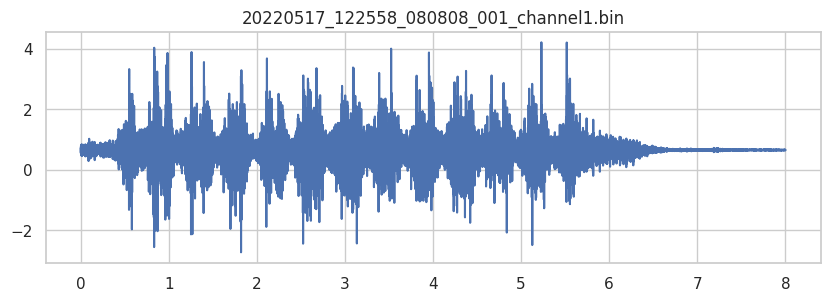

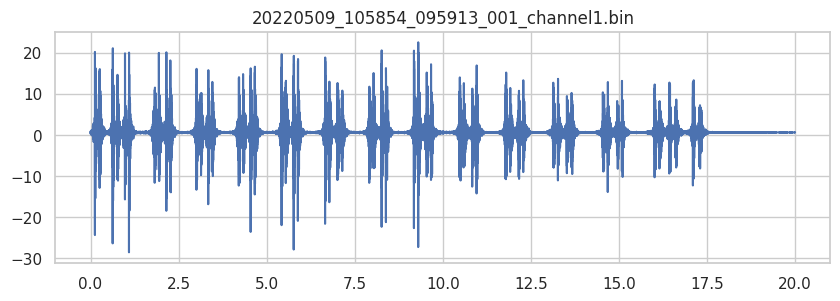

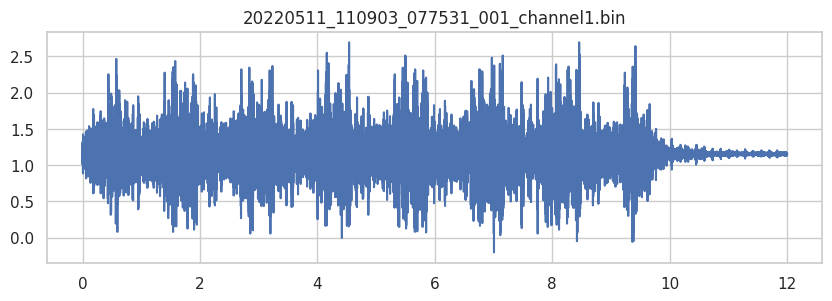

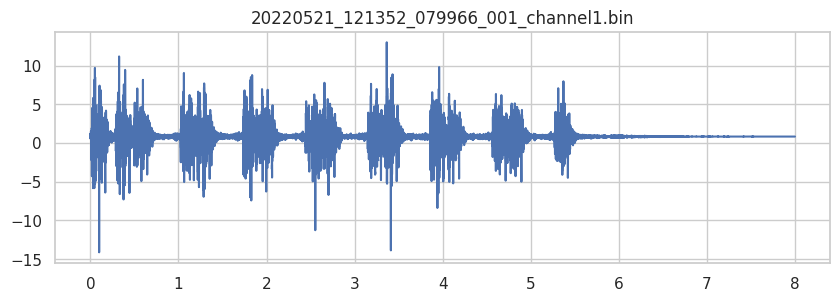

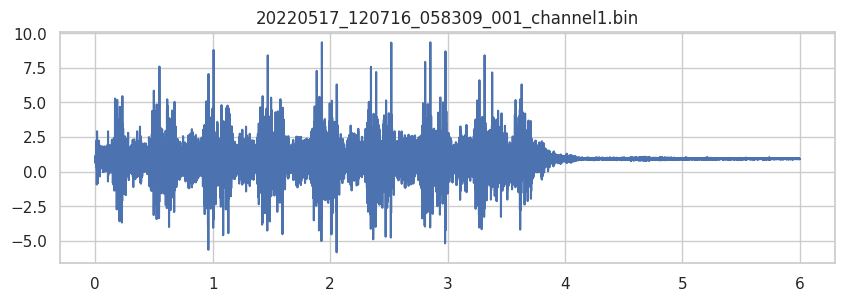

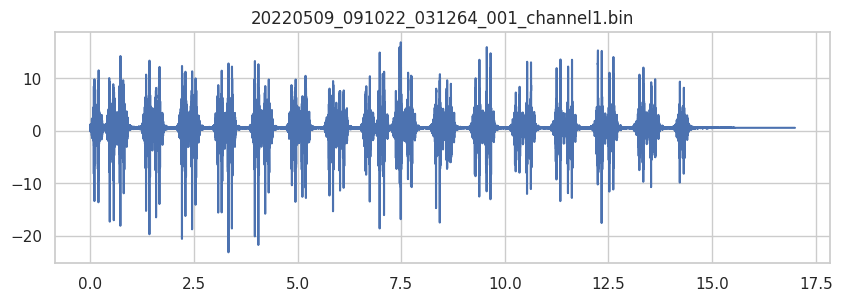

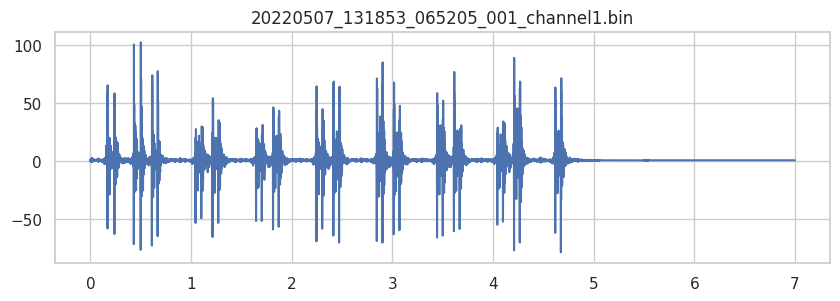

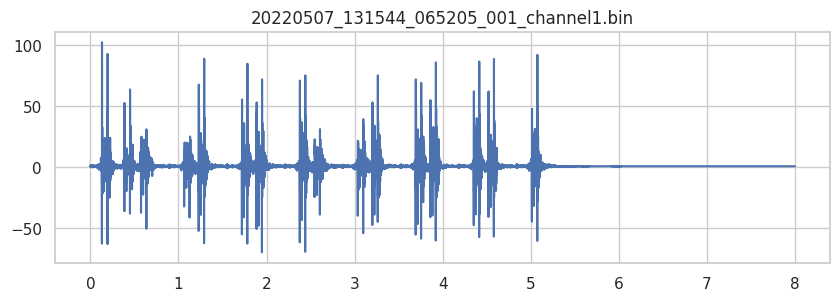

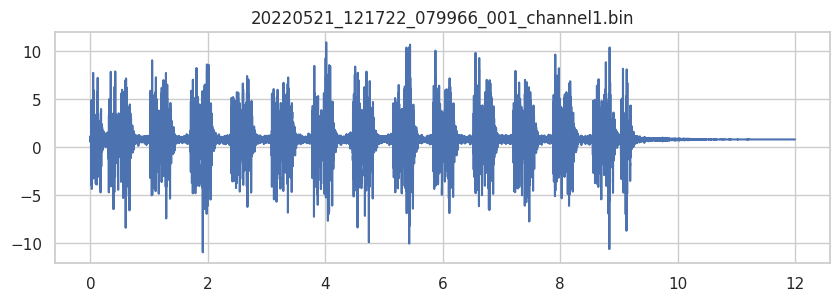

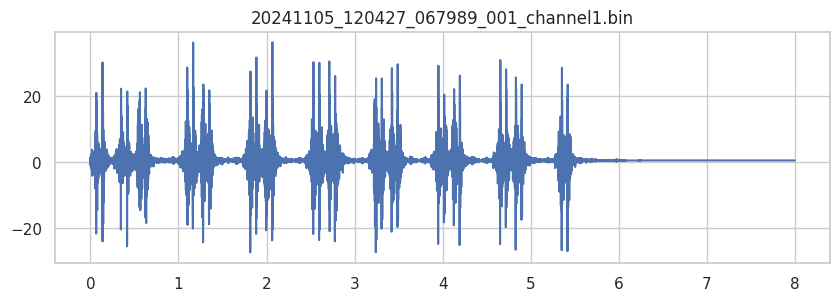

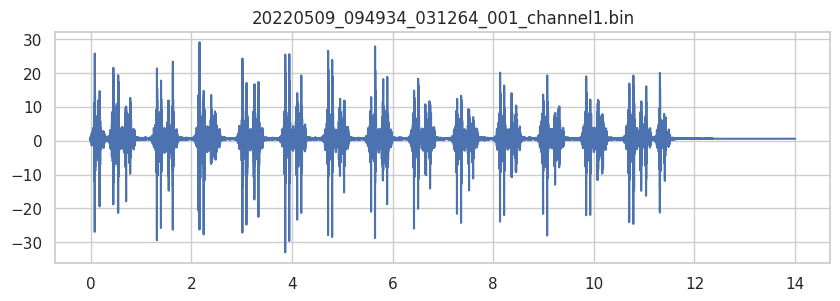

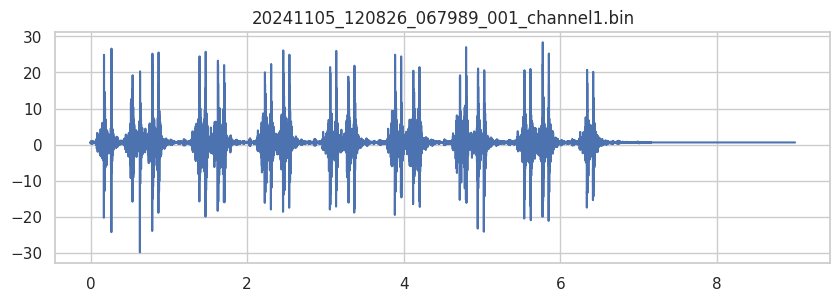

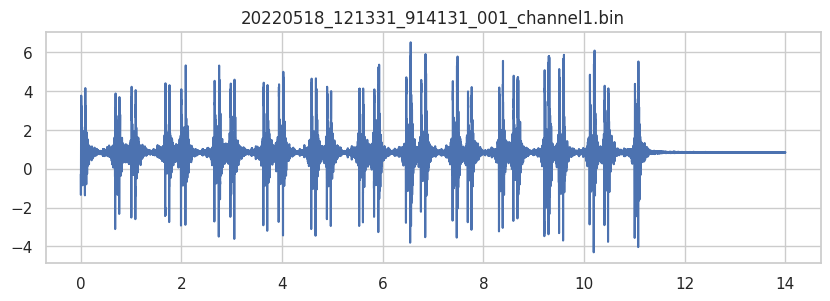

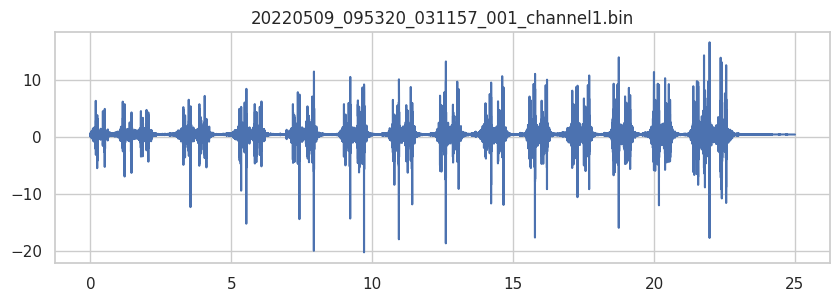

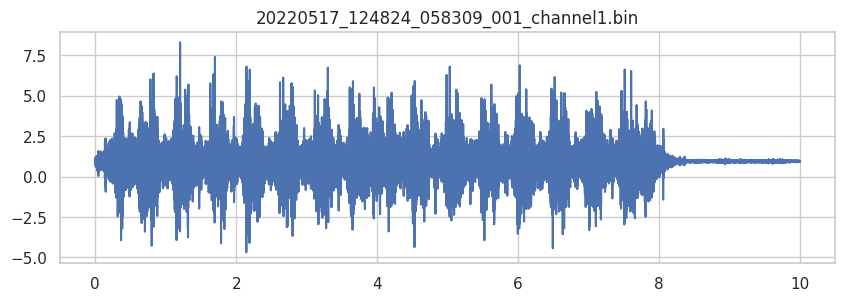

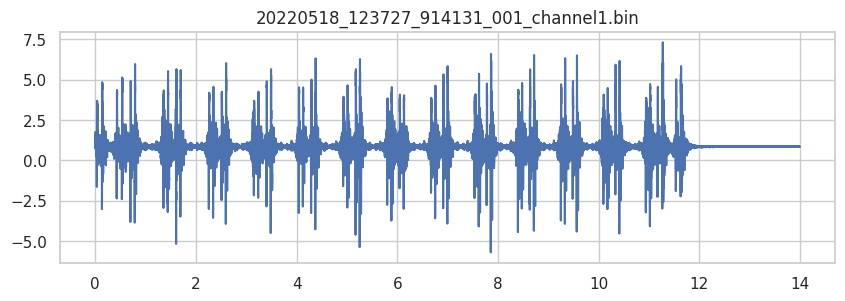

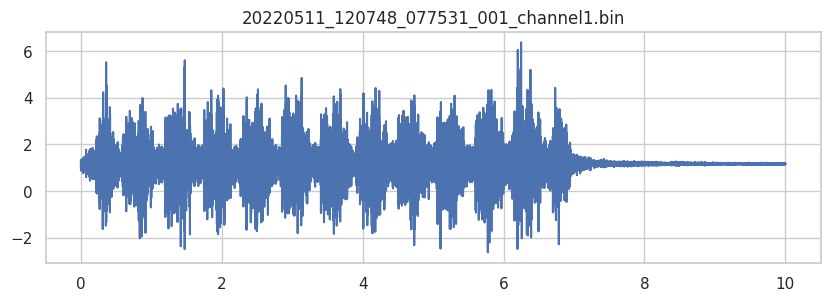

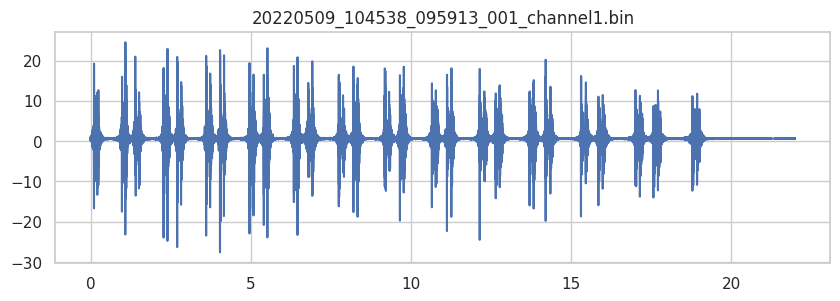

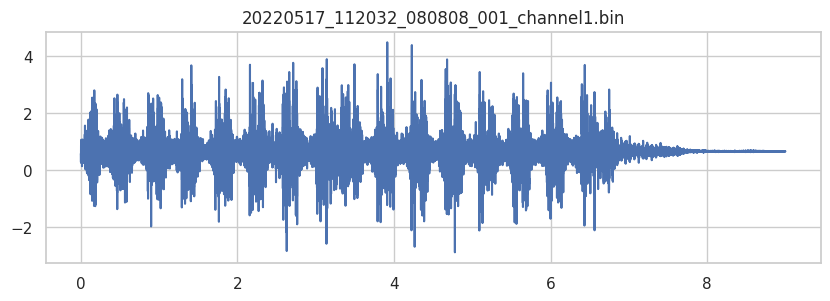

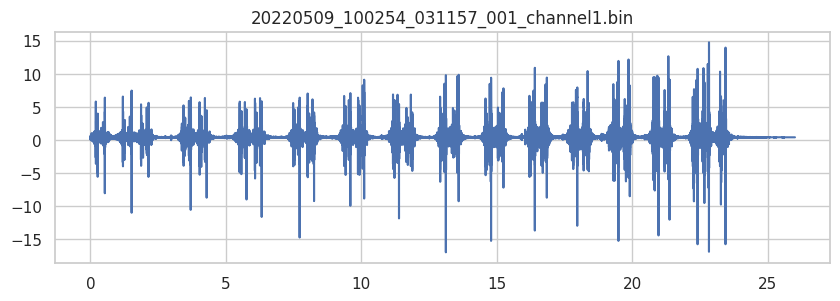

In [4]:
for fname, x in signals.items():
    t = np.arange(len(x))/FS
    plt.figure(figsize=(10,3))
    plt.plot(t, x)
    plt.title(fname)
    plt.grid(True)
    plt.show()


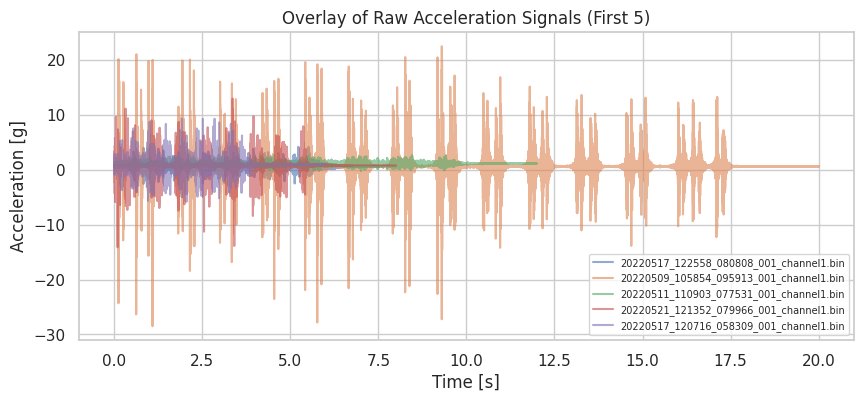

In [5]:
plt.figure(figsize=(10,4))
for fname in list(signals.keys())[:5]:
    x = signals[fname]
    t = np.arange(len(x))/FS
    plt.plot(t, x, alpha=0.6, label=fname)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.title("Overlay of Raw Acceleration Signals (First 5)")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()


In [6]:
signals_filt = {}
segments = {}

for fname, x in signals.items():
    xf = bandpass_filter_zero_phase(x, FS)
    env = rms_envelope(xf, FS)
    s, e = segment_active_region(env, FS)
    signals_filt[fname] = xf
    segments[fname] = (s, e)


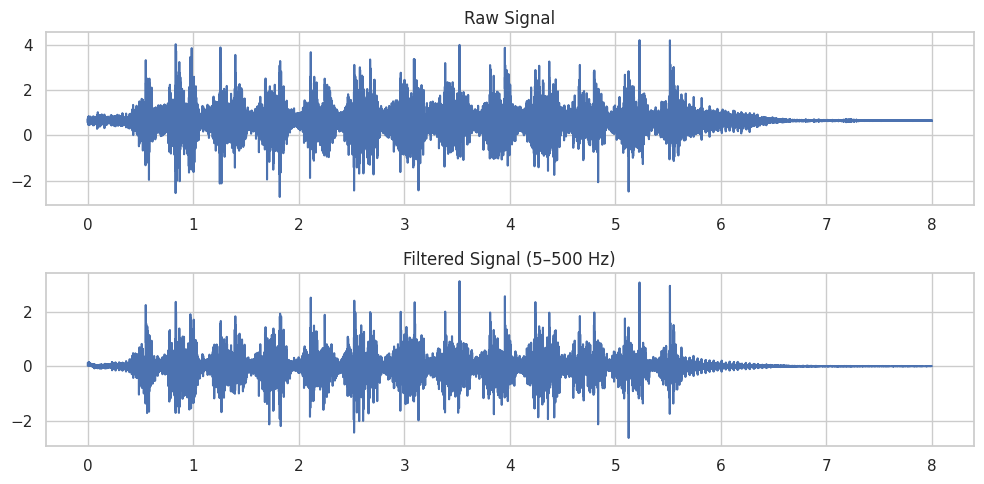

In [7]:
example_file = meta_df.index[0]
x_raw = signals[example_file]
x_filt = signals_filt[example_file]

n = min(len(x_raw), len(x_filt))
t = np.arange(n)/FS

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t, x_raw[:n])
plt.title("Raw Signal")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, x_filt[:n])
plt.title("Filtered Signal (5–500 Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()


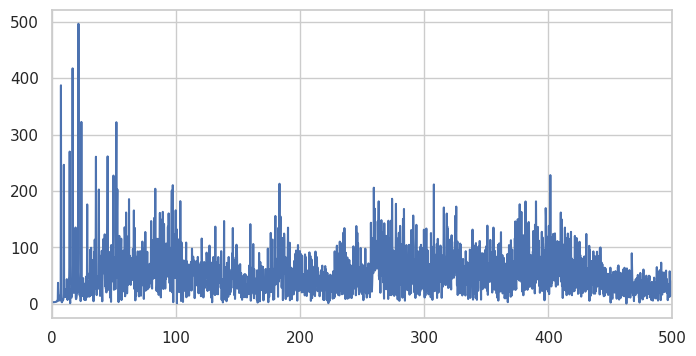

In [8]:
fname = list(signals.keys())[0]
s, e = segments[fname]
xseg = signals_filt[fname][s:e]

yf = np.abs(rfft(xseg))
xf = rfftfreq(len(xseg), 1/FS)

plt.figure(figsize=(8,4))
plt.plot(xf, yf)
plt.xlim(0, 500)
plt.grid(True)
plt.show()


In [9]:
rows = []
for fname in meta_df.index:
    s, e = segments[fname]
    xseg = signals_filt[fname][s:e]

    feats = {}
    feats.update(parse_filename_metadata(fname))
    feats.update(extract_time_features(xseg, FS))
    feats.update(extract_frequency_features(xseg, FS))
    feats["active_duration_s"] = (e-s)/FS
    feats["file"] = fname
    rows.append(feats)

features_df = pd.DataFrame(rows).set_index("file")
features_df


,date,time,sensor_id,rms,peak_to_peak,num_peaks,mean_peak_interval_s,variance,crest_factor,kurtosis,skewness,spectral_centroid_hz,dominant_frequency_hz,spectral_bandwidth_hz,spectral_entropy,energy_5_50,energy_50_200,energy_200_500,active_duration_s
file,,,,,,,,,,,,,,,,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,0.471155,5.744728,1167,0.004371,0.221987,6.608679,3.433789,0.261289,267.979824,21.174395,154.902739,7.786708,1.576425e+06,3.387047e+06,6.401748e+06,5.1005
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,1.570273,44.038942,1716,0.010048,2.465756,15.778270,35.793564,-0.767909,275.537639,153.950000,147.904191,9.147367,5.241887e+07,7.823284e+08,1.058061e+09,20.0000
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,0.274914,2.739692,2632,0.003360,0.075578,5.293995,1.342806,0.116625,281.152262,42.849067,144.655404,8.001703,1.207123e+06,2.442550e+06,8.168026e+06,8.8450
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,1.113906,21.922877,997,0.005470,1.240778,11.188470,11.669400,-0.598958,242.206566,73.500000,148.063550,8.133067,1.457337e+07,8.012199e+07,6.298641e+07,8.0000
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,0.986060,12.799808,375,0.006274,0.972309,7.498115,9.870996,0.829679,281.614718,93.231162,158.363059,6.907965,1.510237e+06,3.206946e+06,5.767694e+06,2.3490
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,1.490862,33.531185,2027,0.007091,2.222669,12.078250,21.874660,-0.336811,270.079287,195.058824,145.863715,8.884932,1.485902e+07,5.798500e+08,6.831385e+08,17.0000
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,6.829386,153.924298,510,0.008943,46.640509,11.281519,34.356516,-0.773819,269.302788,71.714286,141.620713,8.014900,1.119752e+08,1.798520e+09,2.616725e+09,7.0000
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,6.119571,147.311505,583,0.008562,37.449145,12.986165,42.906549,-0.029624,268.039206,65.375000,136.280171,8.122452,1.192286e+08,1.537899e+09,3.102159e+09,8.0000
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,1.497176,18.834176,555,0.006267,2.241535,6.648112,5.332777,-0.312266,254.132015,92.842771,167.010887,7.362115,4.567290e+06,2.643657e+07,2.291758e+07,3.4790


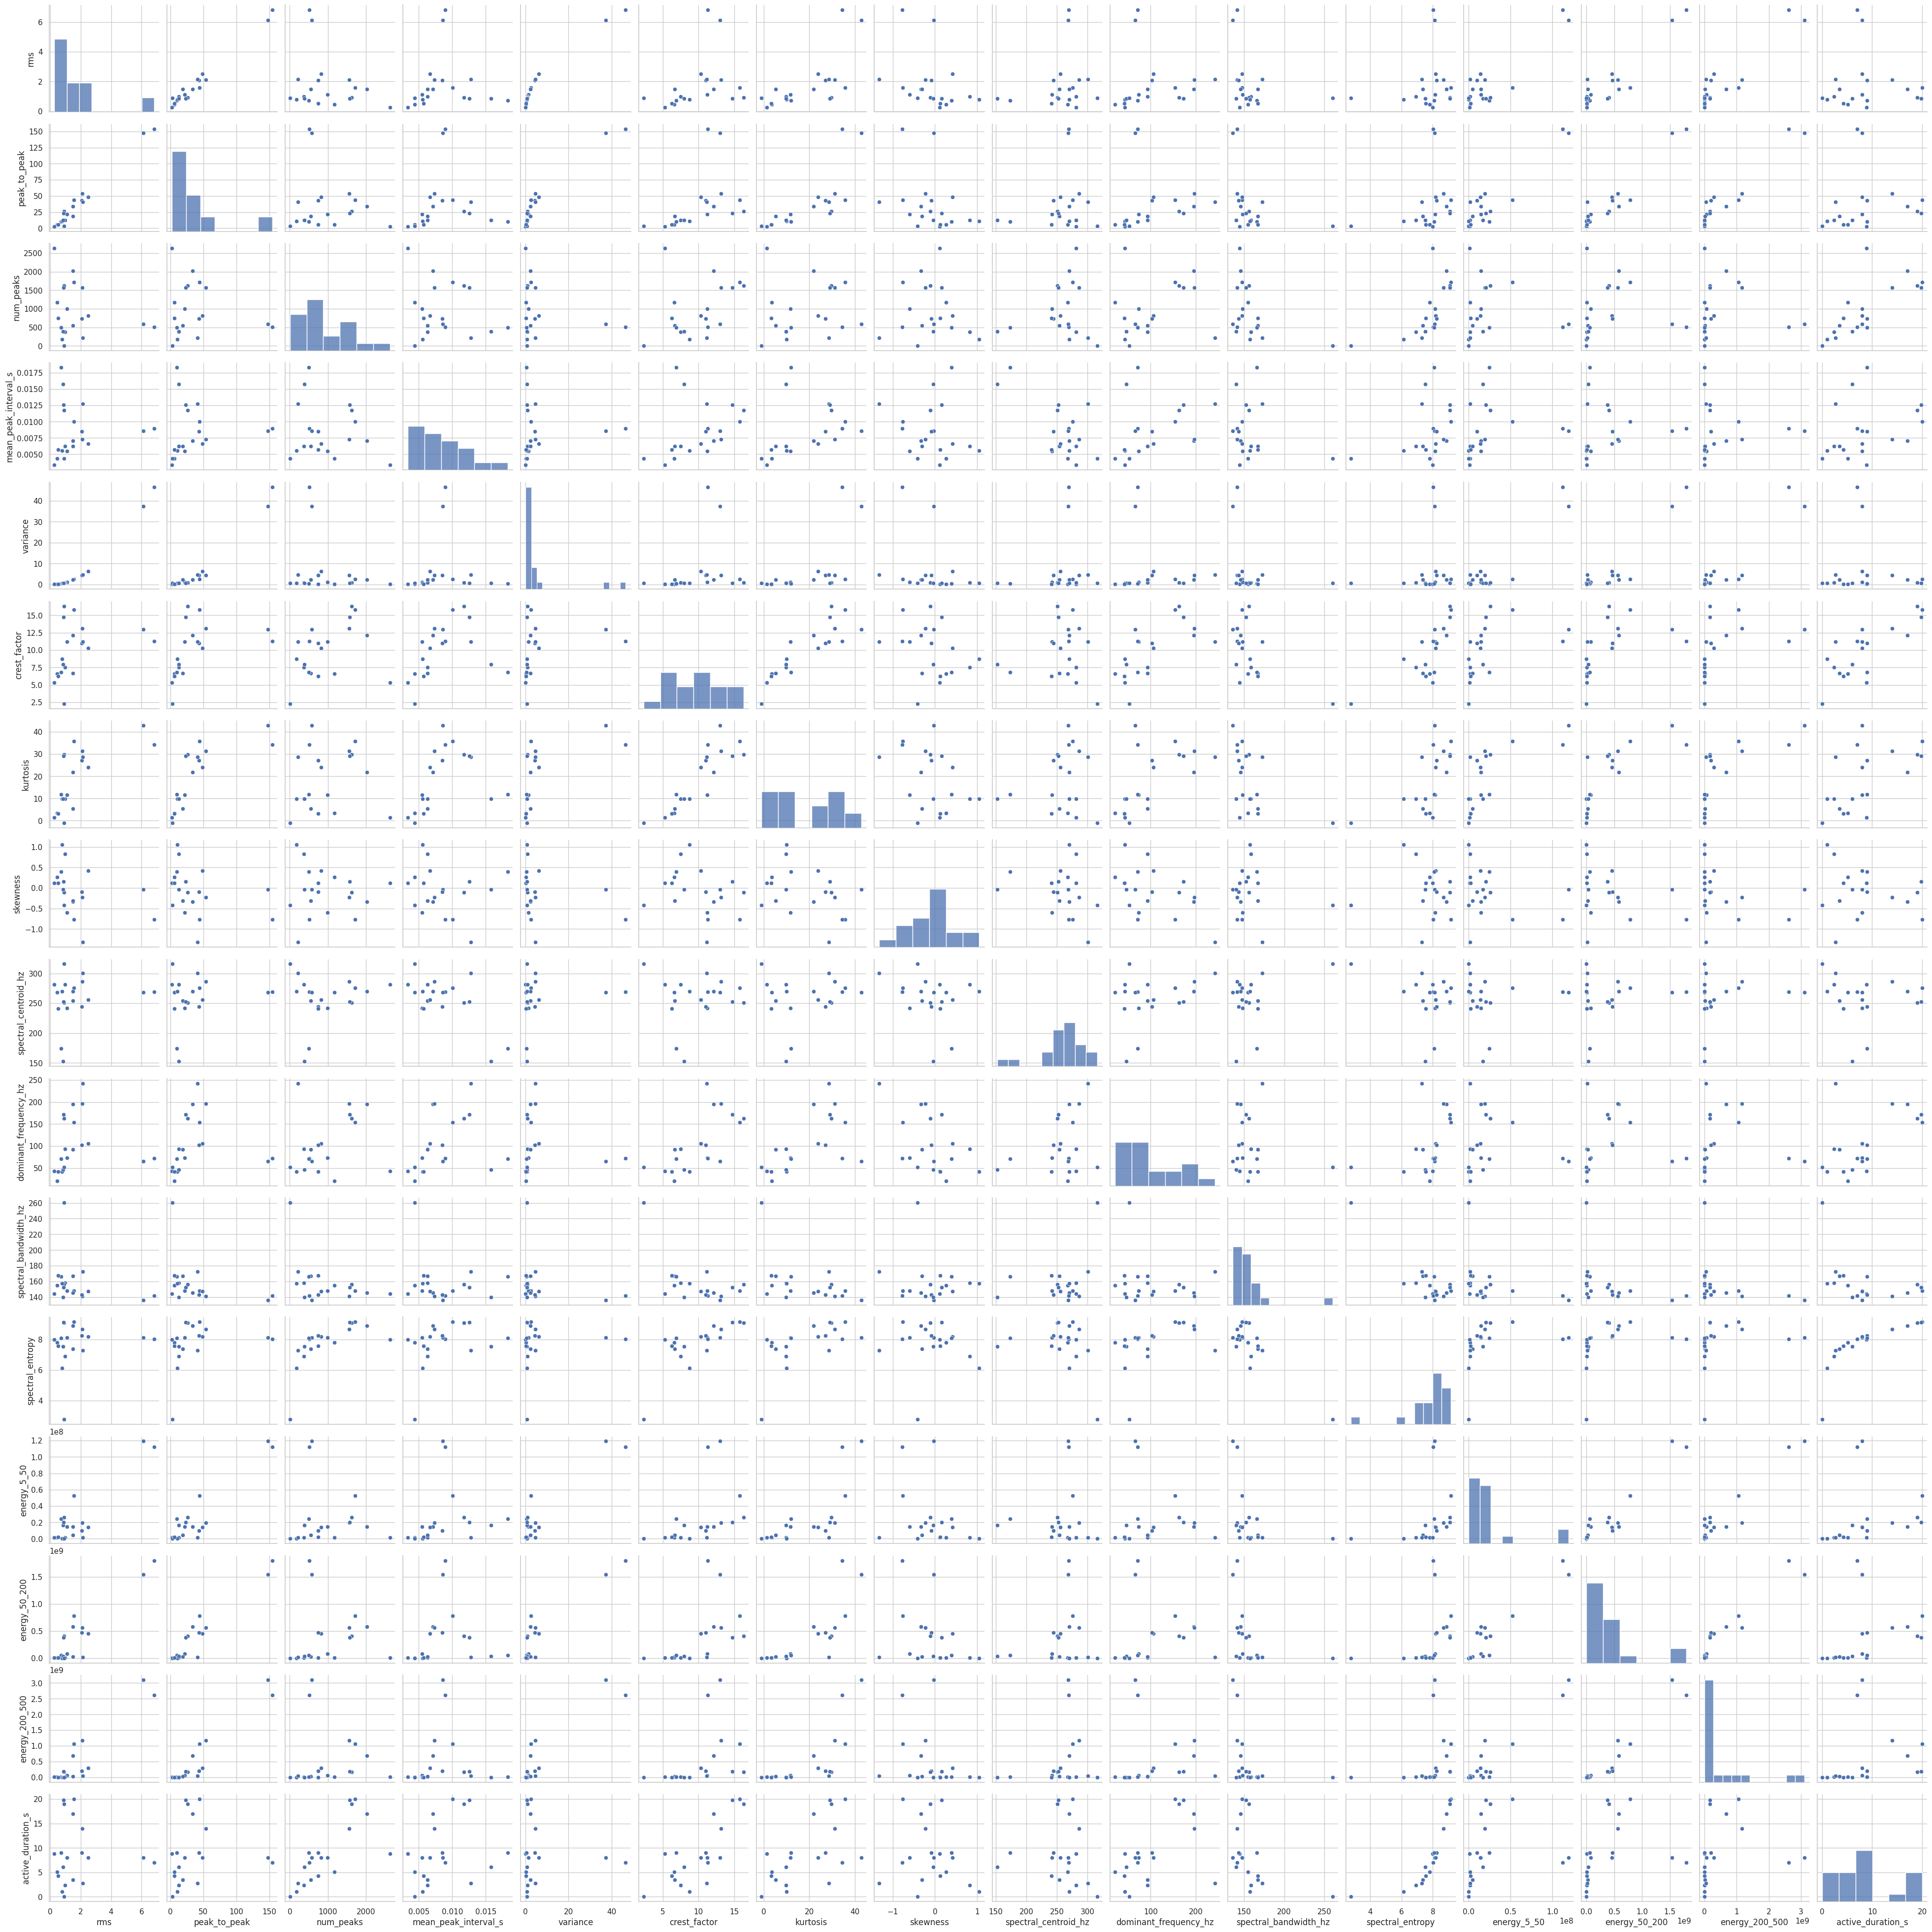

In [10]:
sns.pairplot(features_df.select_dtypes(np.number).dropna())
plt.show()

corr = features_df.select_dtypes(np.number).corr()


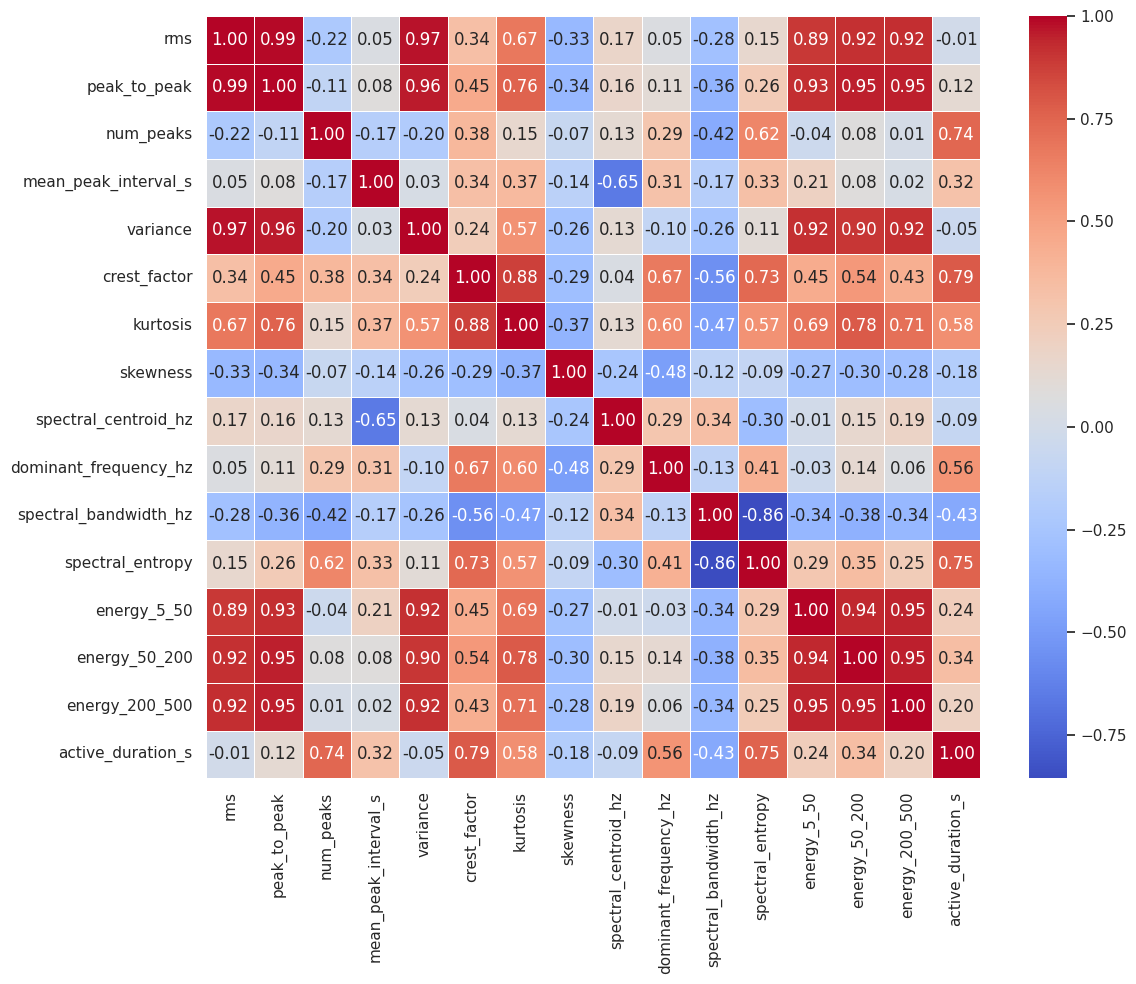

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.tight_layout()
plt.show()


In [12]:
def remove_collinear_with_priority(
    df,
    corr_threshold=0.80,
    priority_features=None
):
    if priority_features is None:
        priority_features = []

    df = df.copy()
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = set()

    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > corr_threshold:
                if col in priority_features:
                    to_drop.add(row)
                elif row in priority_features:
                    to_drop.add(col)
                else:
                    # fallback: variance rule
                    drop = col if df[col].var() < df[row].var() else row
                    to_drop.add(drop)
    print(list(to_drop))
    return df.drop(columns=list(to_drop))


In [13]:
features_df = remove_collinear_with_priority(
    features_df,
    corr_threshold=0.95,
    priority_features=["rms", "energy_50_200", "spectral_entropy"]
)


['peak_to_peak', 'variance', 'energy_200_500']


In [14]:
features_df.head(5)
len(features_df.columns)

16

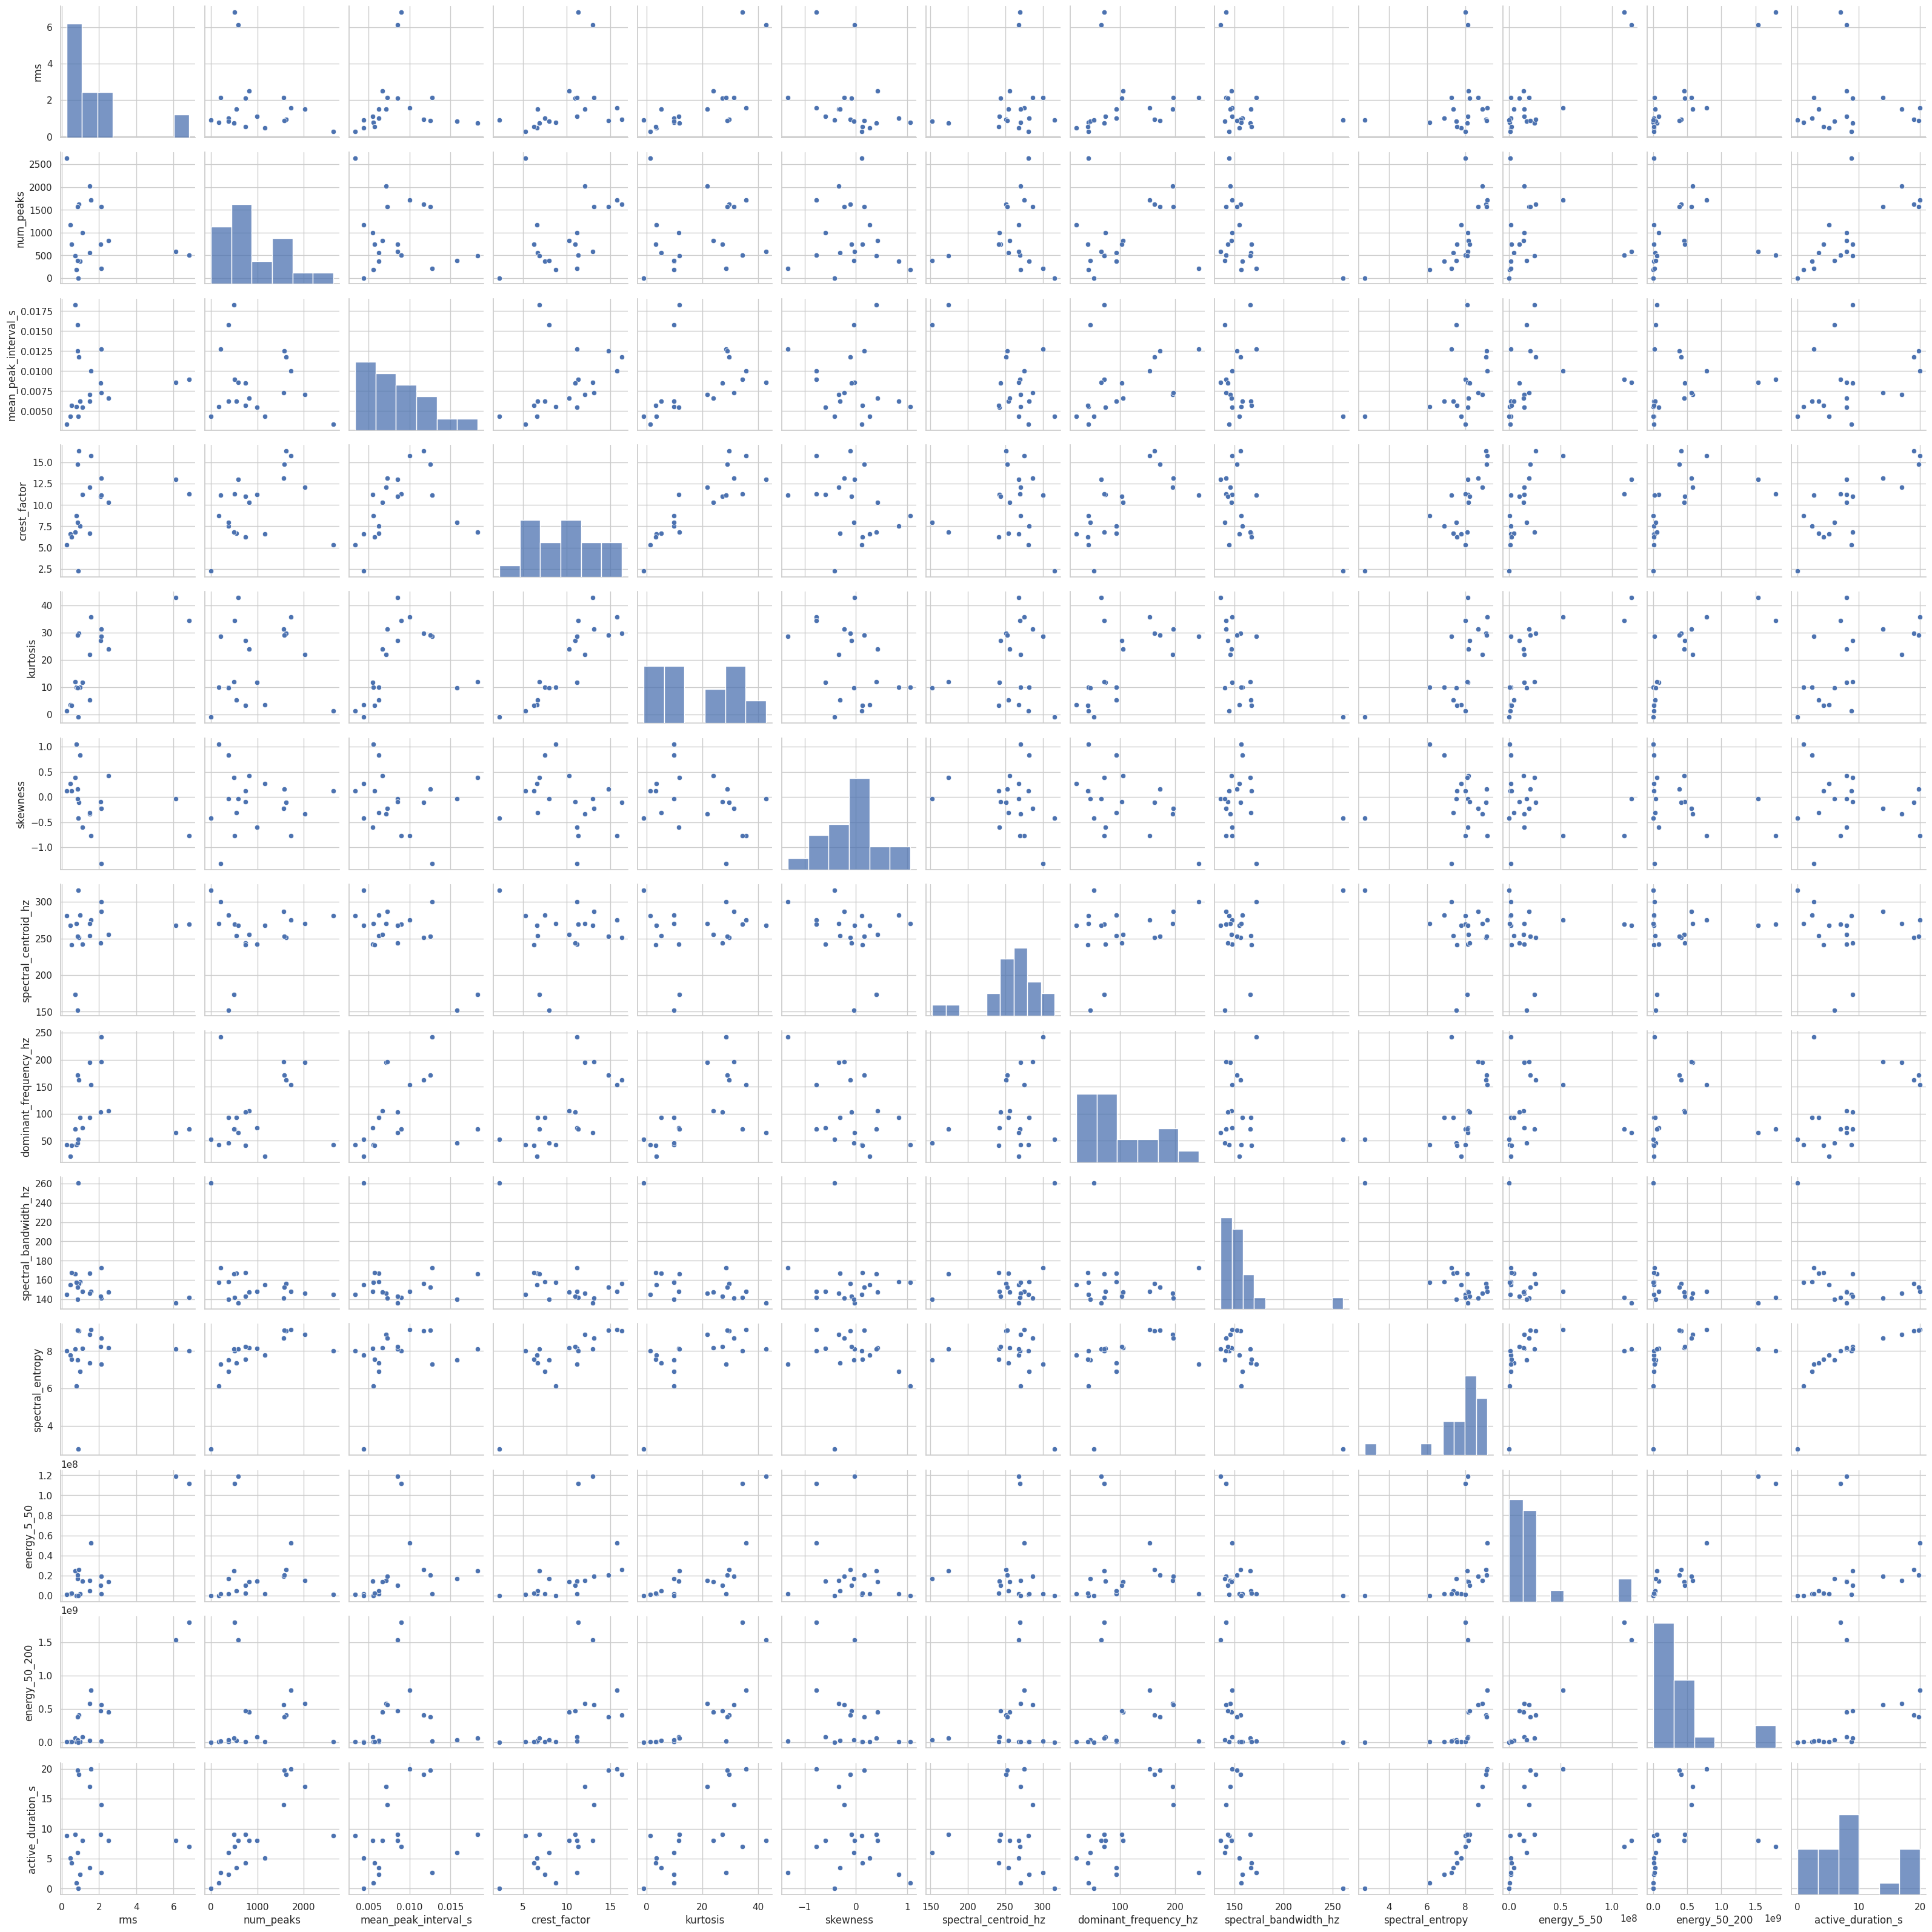

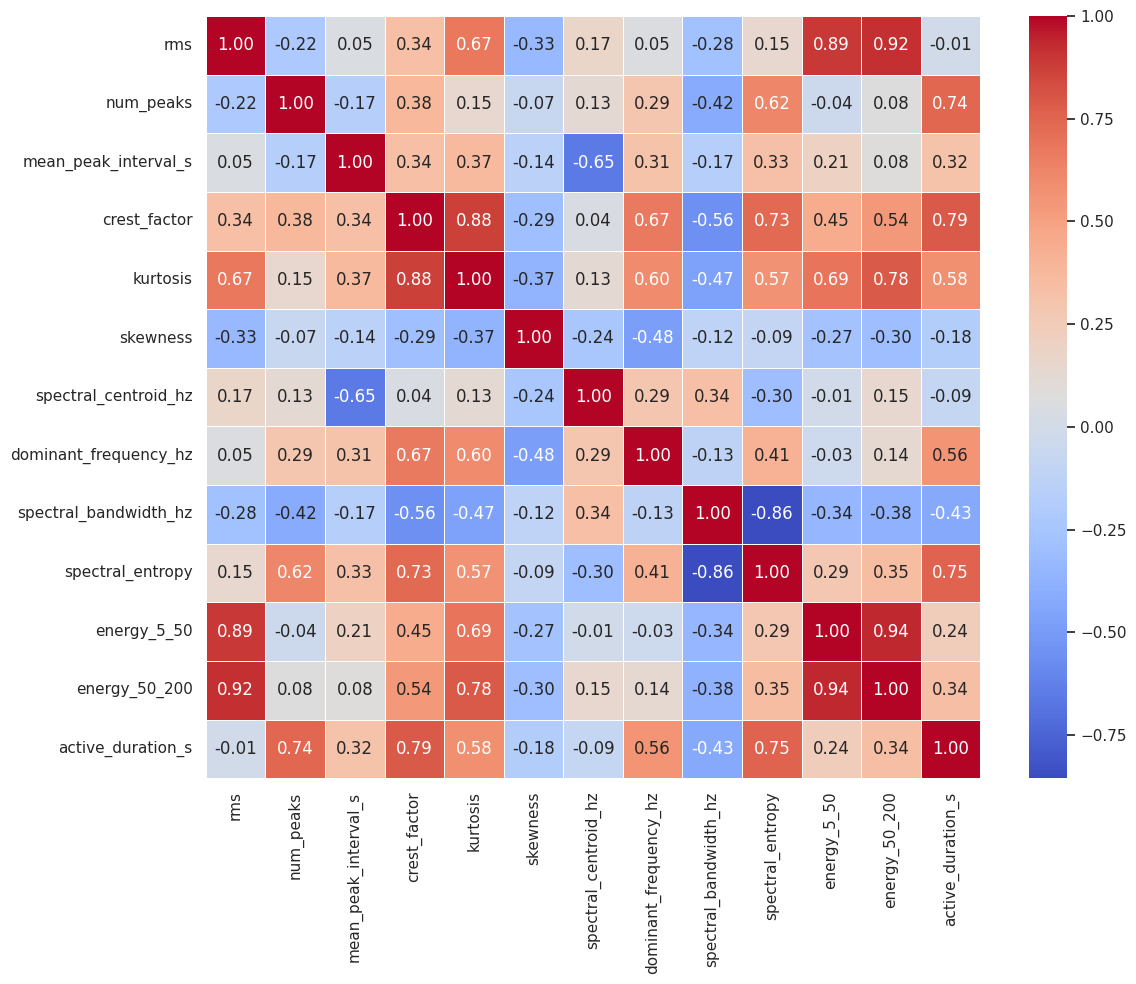

In [15]:
sns.pairplot(features_df.select_dtypes(np.number).dropna())
plt.show()

corr = features_df.select_dtypes(np.number).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.tight_layout()
plt.show()

Original features: 13
PCA components:    5


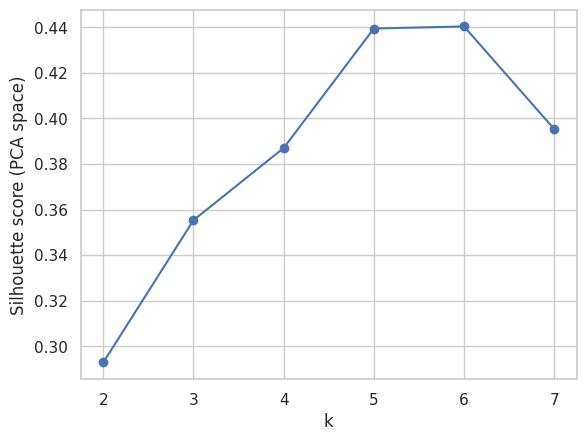

Best k: 6


In [16]:
X = features_df.select_dtypes(include=[np.number])
X = X.fillna(X.mean())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features: {X_scaled.shape[1]}")
print(f"PCA components:    {X_pca.shape[1]}")
k_range = range(2, 8)
scores = []

for k in k_range:
    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(X_pca)

    scores.append(silhouette_score(X_pca, labels))
plt.plot(k_range, scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score (PCA space)")
plt.grid(True)
plt.show()
best_k = k_range[np.argmax(scores)]
print(f"Best k: {best_k}")
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

features_df["cluster"] = kmeans.fit_predict(X_pca)


<Figure size 1400x500 with 0 Axes>

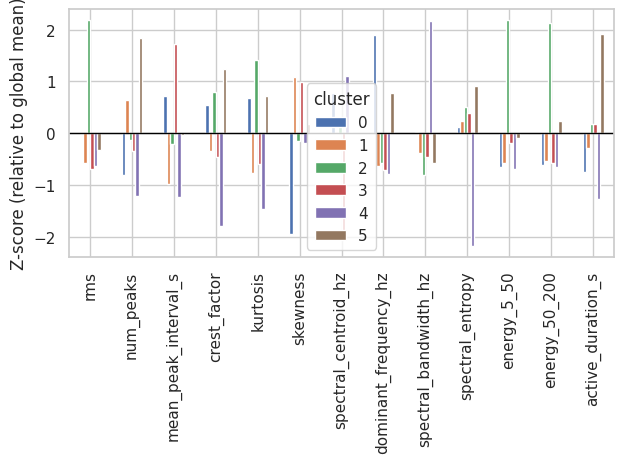

In [17]:
cluster_means = features_df.groupby("cluster").mean(numeric_only=True)

cluster_means_z = cluster_means.apply(zscore)

plt.figure(figsize=(14, 5))
cluster_means_z.T.plot(kind="bar")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Z-score (relative to global mean)")
plt.grid(True)
plt.tight_layout()
plt.show()


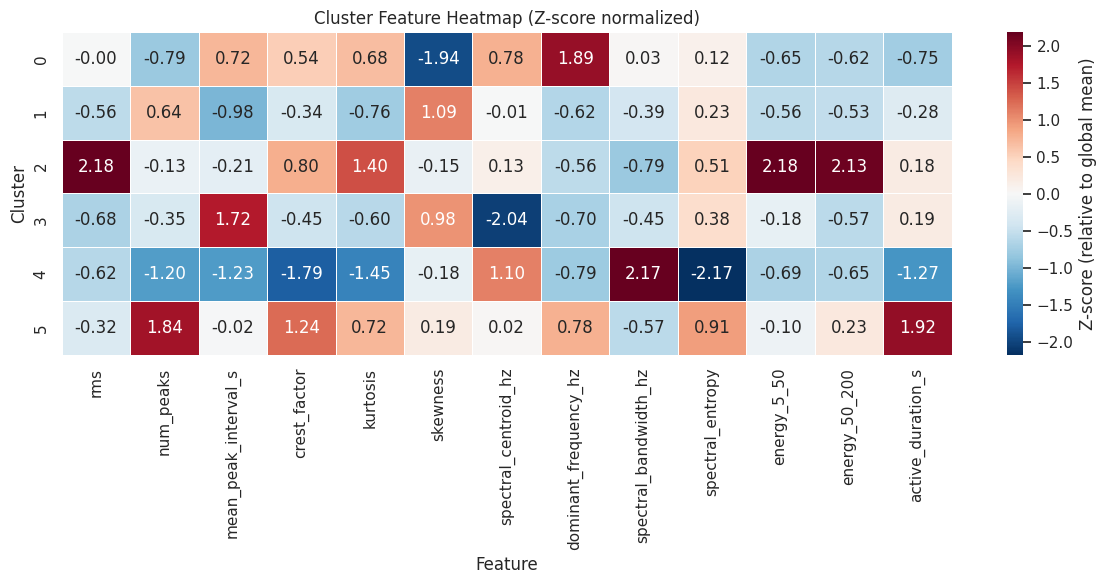

In [18]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_means_z,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Z-score (relative to global mean)"}
)

plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.title("Cluster Feature Heatmap (Z-score normalized)")
plt.tight_layout()
plt.show()


In [19]:
features_df["speed_proxy"] = 1.0 / features_df["mean_peak_interval_s"]


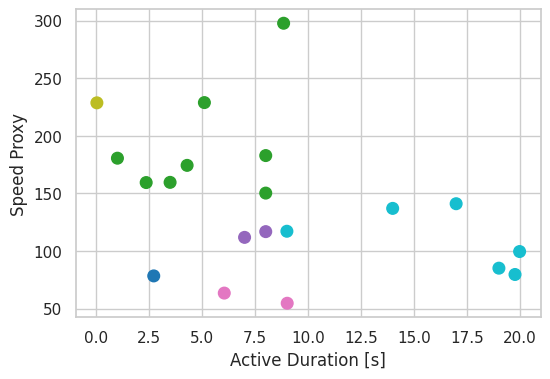

In [20]:

plt.figure(figsize=(6,4))
plt.scatter(
    features_df["active_duration_s"],
    features_df["speed_proxy"],
    c=features_df["cluster"],
    cmap="tab10",
    s=70
)
plt.xlabel("Active Duration [s]")
plt.ylabel("Speed Proxy")
plt.grid(True)
plt.show()


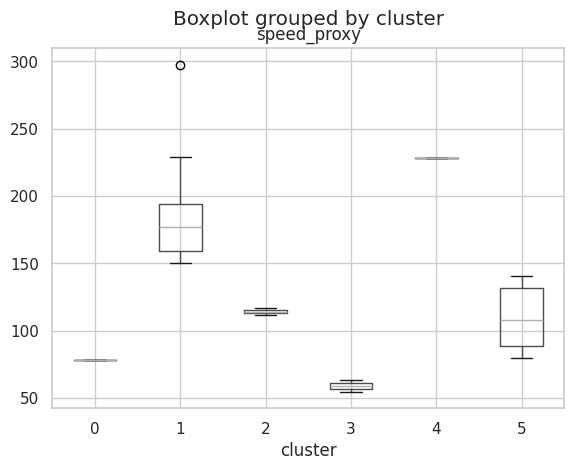

In [21]:
# Speed distribution per cluster
features_df.boxplot(column="speed_proxy", by="cluster")
plt.grid(True)
plt.show()


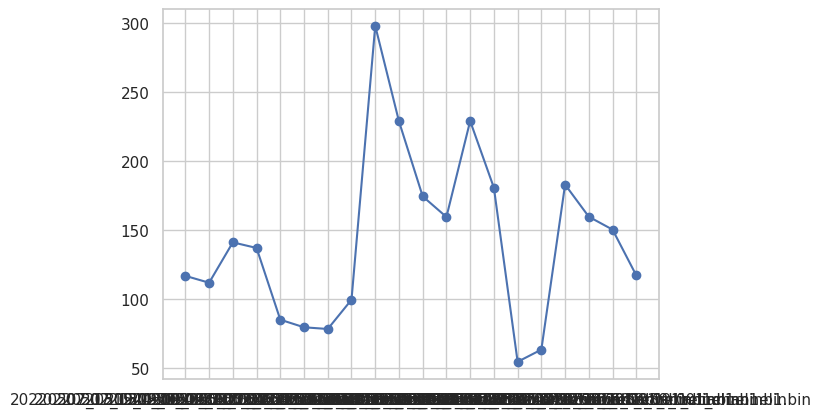

In [22]:
# Speed over time
features_df_sorted = features_df.sort_index()
plt.plot(features_df_sorted["speed_proxy"], marker="o")
plt.grid(True)
plt.show()


In [23]:
features_df["axle_frequency"] = 1.0 / features_df["mean_peak_interval_s"]


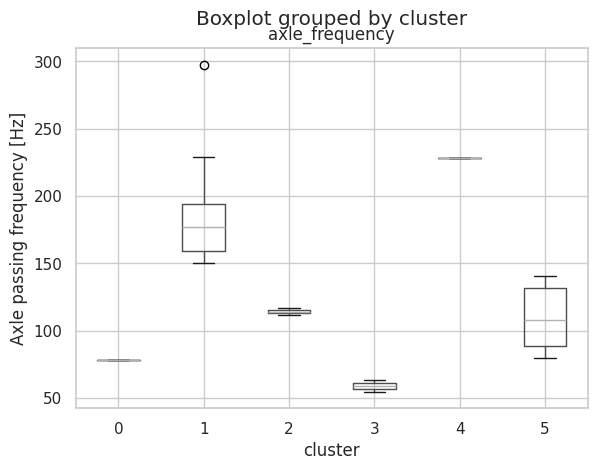

In [24]:
features_df.boxplot(column="axle_frequency", by="cluster")
plt.ylabel("Axle passing frequency [Hz]")
plt.grid(True)
plt.show()


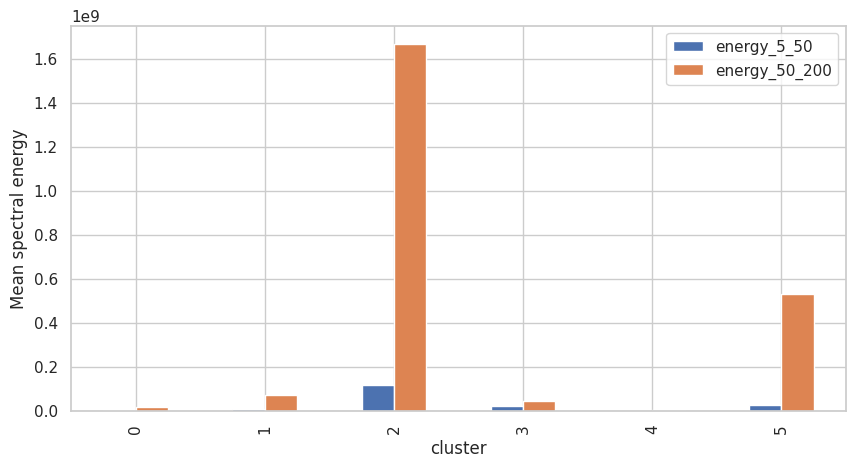

In [25]:
cluster_energy = features_df.groupby("cluster")[[
    "energy_5_50",
    "energy_50_200",
    #"energy_200_500"
]].mean()

cluster_energy.plot(kind="bar", figsize=(10,5))
plt.ylabel("Mean spectral energy")
plt.grid(True)
plt.show()


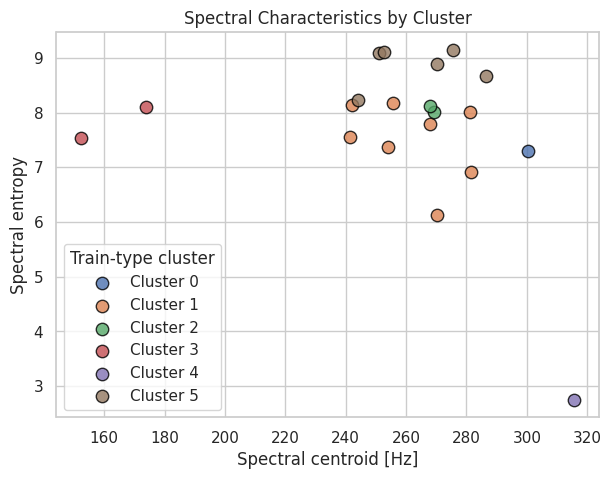

In [26]:
plt.figure(figsize=(7,5))

for cluster_id in sorted(features_df["cluster"].unique()):
    subset = features_df[features_df["cluster"] == cluster_id]
    plt.scatter(
        subset["spectral_centroid_hz"],
        subset["spectral_entropy"],
        label=f"Cluster {cluster_id}",
        s=80,
        alpha=0.8,
        edgecolors="black"
    )

plt.xlabel("Spectral centroid [Hz]")
plt.ylabel("Spectral entropy")
plt.title("Spectral Characteristics by Cluster")
plt.legend(title="Train-type cluster")
plt.grid(True)
plt.show()


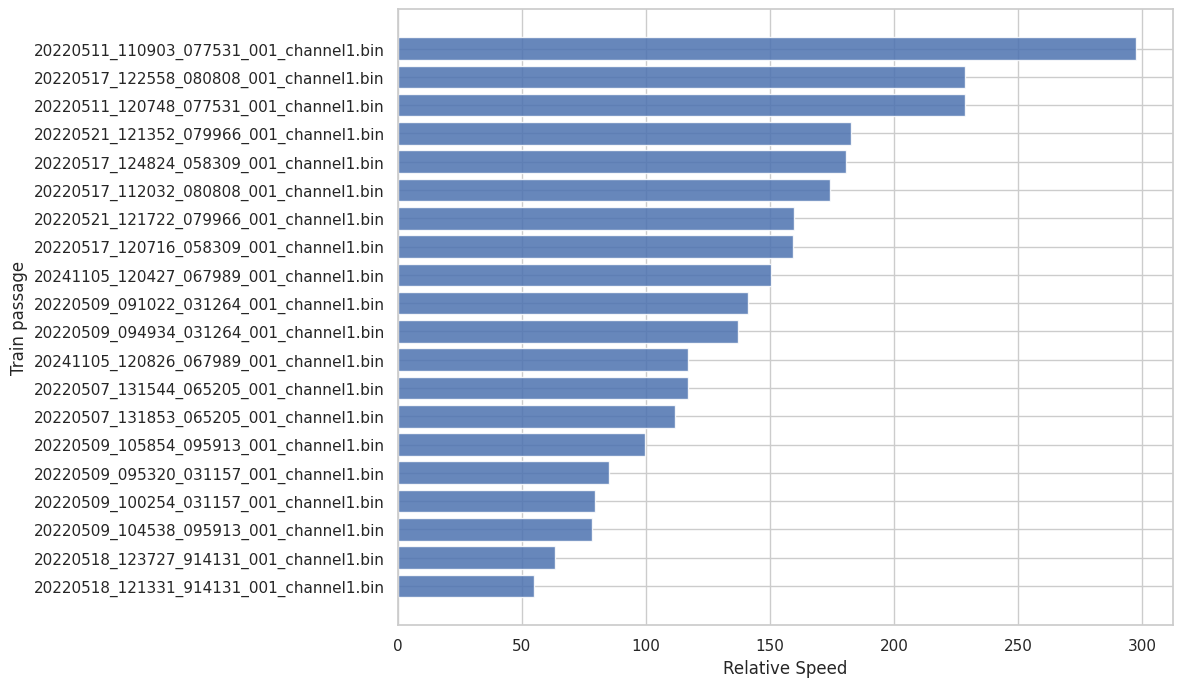

In [27]:
# Horizontal bar charts (speed ranking)
features_df_sorted = features_df.sort_values("speed_proxy")

plt.figure(figsize=(10,8))
plt.barh(features_df_sorted.index, features_df_sorted["speed_proxy"], alpha=0.85)
plt.xlabel("Relative Speed")
plt.ylabel("Train passage")
plt.grid(True)
plt.show()


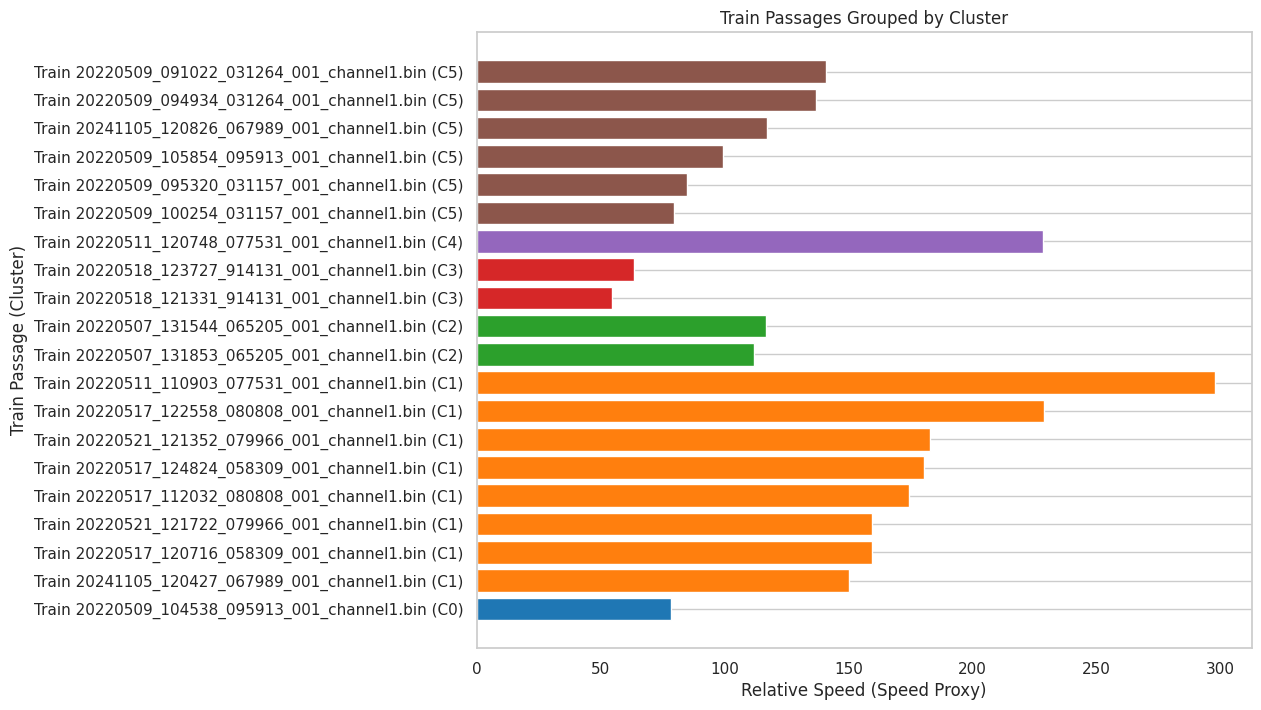

In [28]:
# Sort by cluster, then by speed
features_df_sorted = features_df.sort_values(
    by=["cluster", "speed_proxy"]
)

# Create colors per cluster
palette = sns.color_palette("tab10", features_df_sorted["cluster"].nunique())
cluster_colors = dict(
    zip(features_df_sorted["cluster"].unique(), palette)
)
colors = features_df_sorted["cluster"].map(cluster_colors)

plt.figure(figsize=(10, 8))
plt.barh(
    range(len(features_df_sorted)),
    features_df_sorted["speed_proxy"],
    color=colors
)

# Label y-axis with train index + cluster
plt.yticks(
    range(len(features_df_sorted)),
    [f"Train {i} (C{c})"
     for i, c in zip(features_df_sorted.index,
                     features_df_sorted["cluster"])]
)

plt.xlabel("Relative Speed (Speed Proxy)")
plt.ylabel("Train Passage (Cluster)")
plt.title("Train Passages Grouped by Cluster")
plt.grid(axis="x")
plt.show()
